# GramBank

In [2]:
import pandas as pd
from typing import *
from tqdm import *

grambank_dir = "/media/jaap/81b6ce8a-28e5-4eda-9c68-b13e0637cc4f/Documents/POSTDOC/cross-lingual-tse/resources/"

grambank = pd.read_csv(f'{grambank_dir}grambank/values.csv')
gb_langs = pd.read_csv(f'{grambank_dir}grambank/languages.csv')
id2lang = dict(zip(gb_langs.ID, gb_langs.Name))
lang2id = dict(zip(gb_langs.Name, gb_langs.ID))
lang2fam = dict(zip(gb_langs.Name, gb_langs.Family_name))


def get_grambank_feature(lang, param):
    if lang in lang2id:
        lang = lang2id[lang]

    return grambank[(grambank.Language_ID == lang) & (grambank.Parameter_ID == param)]


def intersect_grambank(parameters: List[str]):
    filtered_langs = []

    for lang, lang_df in grambank.groupby('Language_ID'):
        keep = True
        for param in parameters:
            if len(lang_df[lang_df.Parameter_ID == param].Value) == 0:
                keep = False
                break

            if lang_df[lang_df.Parameter_ID == param].Value.item() != '1':
                keep = False
                break

        if keep:
            filtered_langs.append(lang)
            
    return filtered_langs


sva_ids = intersect_grambank(['GB044', 'GB089', 'GB091'])
sva_langs = [id2lang[id] for id in sva_ids]

ana_ids = intersect_grambank(['GB184', 'GB044'])
ana_langs = [id2lang[id] for id in ana_ids] + ["Dutch"]

In [3]:
full_df = pd.read_csv("full_df.csv", low_memory=False)

In [1]:
import pickle

with open("lang2data.pickle", "rb") as f:
    lang2data = pickle.load(f)

In [149]:
from tqdm import tqdm_notebook
from src.multiblimp.languages import gblang2udlang
from src.word_order.viz_overview import calculate_tree_entropy, calculate_base_entropy

udlang2gblang = {ud: gb for gb, ud in gblang2udlang.items()}

rows = []

for lang, (dt, lang_df) in tqdm_notebook(lang2data.items()):
    lang = lang.replace("_", " ")
    lang = udlang2gblang.get(lang, lang)

    arg_distribution = Counter(lang_df.core_args)
    total = arg_distribution.total()
    
    v_first = (arg_distribution['vso'] + arg_distribution['vos']) / total
    v_middle = (arg_distribution['svo'] + arg_distribution['ovs']) / total
    v_last = (arg_distribution['osv'] + arg_distribution['sov']) / total

    gb_v_first = get_grambank_feature(lang, "GB131").Value
    
    if (len(gb_v_first) == 1):
        gb_v_middle = get_grambank_feature(lang, "GB132").Value
        gb_v_last = get_grambank_feature(lang, "GB133").Value

        gb_fixed = get_grambank_feature(lang, "GB136").Value
        if len(gb_fixed) == 1:
            gb_fixed = gb_fixed.iloc[0].replace('0', 'Free').replace('1', 'Fixed').replace('?', 'Unknown')
        else:
            gb_fixed = None

        base_ent = calculate_base_entropy(lang_df, "core_args", binary=True, smoothing=0.5)
        reduced_ent = calculate_tree_entropy(dt, lang_df, "core_args", binary=True, smoothing=0.5)
        
        rows.append([lang, v_first, v_middle, v_last, int(gb_v_first.iloc[0]), int(gb_v_middle.iloc[0]), int(gb_v_last.iloc[0]), gb_fixed, base_ent, reduced_ent])
    elif len(gb_v_first) == 0:
        print(lang, "not found")
    else:
        print(lang, "multiple matches")

print(len(rows))

/tmp/ipykernel_20993/2783045158.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for lang, (dt, lang_df) in tqdm_notebook(lang2data.items()):


  0%|          | 0/148 [00:00<?, ?it/s]

Abaza not found
Afrikaans not found
Apurina not found
Bavarian not found
Bokota not found
Bulgarian not found
Buryat not found
Cantonese not found
Cappadocian not found
Classical Chinese not found
Croatian not found
Egyptian not found
Esperanto not found
Frisian Dutch not found
German not found
Gheg not found
Gothic not found
Gujarati not found
Haitian Creole not found
Hittite not found
Ika not found
Kaapor not found
Kangri not found
Karo not found
Kazakh not found
Khoekhoe not found
Kiche not found
Komi Permyak not found
Komi Zyrian not found
Kurmanji not found
Kyrgyz not found
Ligurian not found
Low Saxon not found
Maghrebi Arabic French not found
Manx not found
Mbya Guarani not found
Middle French not found
Munduruku not found
Naga not found
Naija not found
Nheengatu not found
North Sami not found
Norwegian Bokmål not found
Norwegian Nynorsk not found
Old Church Slavonic not found
Old East Slavic not found
Old French not found
Ottoman Turkish not found
Phrygian not found
Pomak not f

In [150]:
import math

def calc_entropy(probabilities):
    entropy = 0
    for p in probabilities:
        if p > 0:  # Avoid log(0)
            entropy -= p * math.log2(p)

    return entropy


gb_df = pd.DataFrame(rows, columns=['lang', 'v_first', 'v_middle', 'v_last', 'gb_v_first', 'gb_v_middle', 'gb_v_last', 'gb_fixed', 'base_ent', 'reduced_ent'])

gb_df['num_labels'] = np.sum(gb_df[['gb_v_first', 'gb_v_middle', 'gb_v_last']], axis=1)

gb_df = gb_df[gb_df['num_labels'] == 1]

gb_df['gb_pred'] = [
    ['first', 'middle', 'last'][row.gb_v_first + 2*row.gb_v_middle + 3*row.gb_v_last - 1]
    for _, row in gb_df.iterrows()
]
gb_df['ud_pred'] = [
    {
        "first": row.v_first,
        "middle": row.v_middle,
        "last": row.v_last,
    }[row.gb_pred]
    for _, row in gb_df.iterrows()
]

print(len(gb_df))

69


Text(2.05, 0.3466666666666667, 'Hungarian')

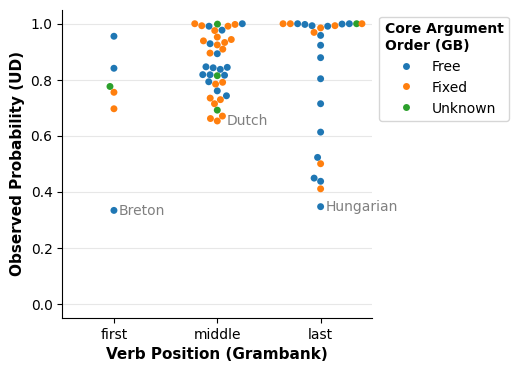

In [156]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 4))

sns.swarmplot(
    data=gb_df,
    x='gb_pred',
    y='ud_pred',
    hue='gb_fixed',
    order=['first', 'middle', 'last']
)

ax.set_ylabel('Observed Probability (UD)', fontweight="bold", fontsize=11)
ax.set_xlabel('Verb Position (Grambank)', fontweight="bold", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, axis='y', alpha=0.3)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend(bbox_to_anchor=(1,1), title='Core Argument\nOrder (GB)', title_fontproperties={'weight':'bold'})

outlier_first = gb_df[(gb_df.gb_pred == 'first') & (gb_df.ud_pred < 0.4)].iloc[0]
ax.text(0.05, outlier_first.ud_pred, outlier_first.lang, ha='left', va='center', color='0.5')

outlier_last = gb_df[(gb_df.gb_pred == 'middle') & (gb_df.ud_pred < 0.66)].iloc[0]
ax.text(1.09, outlier_last.ud_pred, outlier_last.lang, ha='left', va='center', color='0.5')

outlier_last = gb_df[(gb_df.gb_pred == 'last') & (gb_df.ud_pred < 0.4)].iloc[0]
ax.text(2.05, outlier_last.ud_pred, outlier_last.lang, ha='left', va='center', color='0.5')

/tmp/ipykernel_20993/3446599462.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Free", "Fixed", "Unknown"])


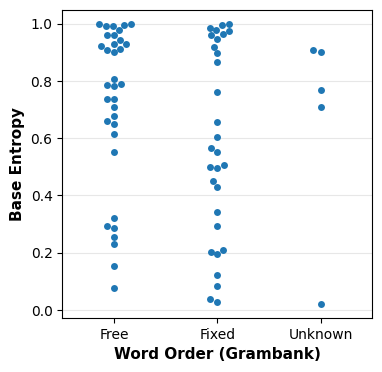

In [121]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 4))

sns.swarmplot(
    data=gb_df,
    x='gb_fixed',
    y='base_ent',
    order=['0', '1', '?']
)

ax.set_ylabel('Base Entropy', fontweight="bold", fontsize=11)
ax.set_xlabel('Word Order (Grambank)', fontweight="bold", fontsize=11)
# ax.set_ylim(-0.05, 1.05)
ax.set_xticklabels(["Free", "Fixed", "Unknown"])
ax.grid(True, axis='y', alpha=0.3)


/tmp/ipykernel_20993/4264649461.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Free", "Fixed", "Unknown"])


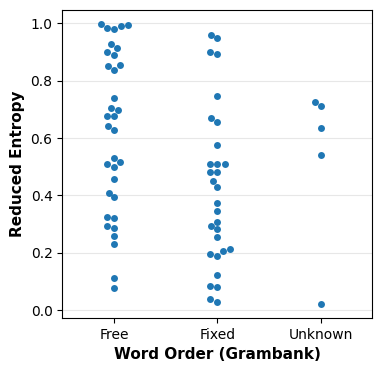

In [123]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 4))

sns.swarmplot(
    data=gb_df,
    x='gb_fixed',
    y='reduced_ent',
    order=['0', '1', '?']
)

ax.set_ylabel('Reduced Entropy', fontweight="bold", fontsize=11)
ax.set_xlabel('Word Order (Grambank)', fontweight="bold", fontsize=11)
# ax.set_ylim(-0.05, 1.05)
ax.set_xticklabels(["Free", "Fixed", "Unknown"])
ax.grid(True, axis='y', alpha=0.3)


/tmp/ipykernel_20993/1153412142.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Free", "Fixed", "Unknown"])
/home/jaap/gpu/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/jaap/gpu/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


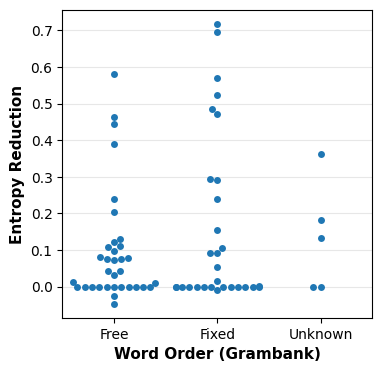

In [127]:
gb_df['ent_reduction'] = gb_df.base_ent - gb_df.reduced_ent

import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 4))

sns.swarmplot(
    data=gb_df,
    x='gb_fixed',
    y='ent_reduction',
    order=['0', '1', '?']
)

ax.set_ylabel('Entropy Reduction', fontweight="bold", fontsize=11)
ax.set_xlabel('Word Order (Grambank)', fontweight="bold", fontsize=11)
# ax.set_ylim(-0.05, 1.05)
ax.set_xticklabels(["Free", "Fixed", "Unknown"])
ax.grid(True, axis='y', alpha=0.3)


# DT Analysis

In [1]:
import pickle

with open("lang2data.pickle", "rb") as f:
    lang2data = pickle.load(f)

In [2]:
from src.word_order.viz_tree import clean_rule, get_correlated_features
from tqdm import tqdm_notebook


lang2rules = {}
lang2idx = {}
idx2lang = []

for lang, (dt, df) in tqdm_notebook(lang2data.items()):        
    clf = dt.named_steps["clf"]
    tree = clf.tree_
    
    prep = dt.named_steps["preprocessor"]
    feature_corrs = get_correlated_features(prep, df)
    
    node_ids = tree.feature
    feature_map = dt.named_steps["preprocessor"].get_feature_names_out()
    tree_features = [
        clean_rule(feature_map[idx]) for idx in node_ids if idx > 0
    ]
    corr_features = [
        corr_rule 
        for rule in tree_features
        for corr_rule in feature_corrs[rule]
    ]
    if len(tree_features) > 0:
        lang2rules[lang] = set(tree_features), set(corr_features), feature_corrs

        lang2idx[lang] = len(lang2idx)
        idx2lang.append(lang)

/tmp/ipykernel_21163/2674008853.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for lang, (dt, df) in tqdm_notebook(lang2data.items()):


  0%|          | 0/148 [00:00<?, ?it/s]

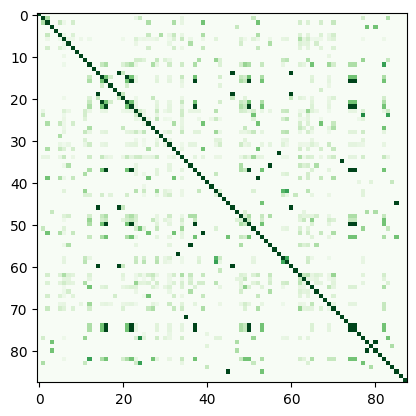

In [18]:
import numpy as np
import matplotlib.pyplot as plt


overlap = np.zeros((len(lang2rules), len(lang2rules)))

for i, (lang1, (rules1, _, _)) in enumerate(lang2rules.items()):
    for j, (lang2, (rules2, _, _)) in enumerate(lang2rules.items()):
        overlap[i, j] = len(rules1 & rules2) / len(rules1.union(rules2))

plt.imshow(overlap, cmap='Greens')

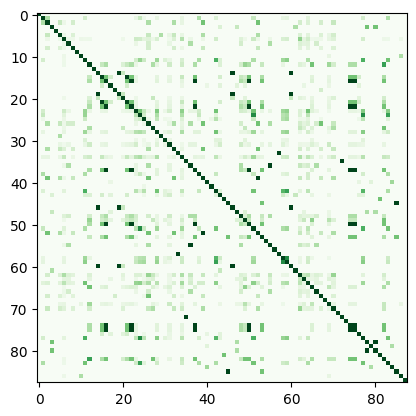

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


overlap2 = np.zeros((len(lang2rules), len(lang2rules)))
pair2overlap = defaultdict(set)

for i, (lang1, (rules1, corr_rules1, feature_corrs1)) in enumerate(lang2rules.items()):
    for j, (lang2, (rules2, corr_rules2, _)) in enumerate(lang2rules.items()):
        n_items_intersection = 0
        
        for r1 in rules1:
            if r1 in rules2 or r1 in corr_rules2:
                n_items_intersection += 1
                pair2overlap[lang1, lang2].add(r1)
            else:
                for r1_corr in feature_corrs1[r1]:
                    if r1_corr in rules2 or r1_corr in corr_rules2:
                        n_items_intersection += 1
                        pair2overlap[lang1, lang2].add(r1_corr)
                        break

        overlap2[i, j] = n_items_intersection / len(rules1.union(rules2))

plt.imshow(overlap2, cmap='Greens')

In [11]:
high_overlap = overlap2*((overlap2>0.5)*(overlap2<1.0))

for lang1, lang_overlaps in zip(lang2rules.keys(), high_overlap):
    for lang2, overlap in zip(lang2rules.keys(), lang_overlaps):
        if overlap > 0:
            print(lang1, lang2)

Bavarian Icelandic
Bavarian Swedish
Belarusian Ukrainian
Danish Low_Saxon
Danish Swedish
Danish Upper_Sorbian
Icelandic Bavarian
Icelandic Norwegian_Bokmål
Icelandic Norwegian_Nynorsk
Icelandic Swedish
Low_Saxon Danish
Low_Saxon Swedish
Norwegian_Bokmål Icelandic
Norwegian_Bokmål Norwegian_Nynorsk
Norwegian_Nynorsk Icelandic
Norwegian_Nynorsk Norwegian_Bokmål
Swedish Bavarian
Swedish Danish
Swedish Icelandic
Swedish Low_Saxon
Ukrainian Belarusian
Upper_Sorbian Danish


In [44]:
pair2overlap["Ukrainian", "Belarusian"]

{'object.PronType is not set', 'subject.pos = PRON'}

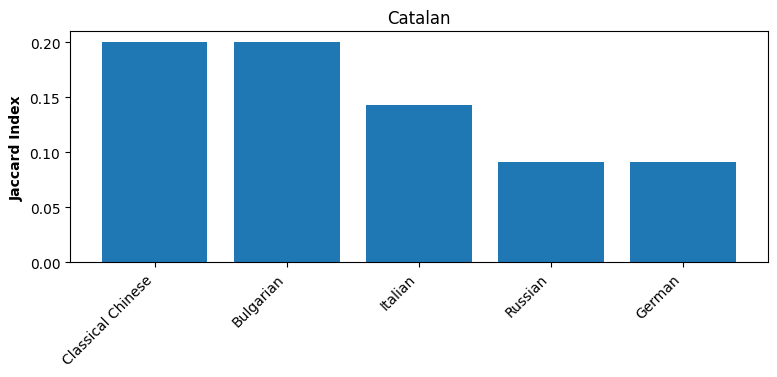

In [30]:
lang = "Catalan"
lang_overlap = overlap[lang2idx[lang]]

plt.figure(figsize=(9,3))

arg_idx = np.argsort(-lang_overlap)[1:]
sim_scores = np.sort(lang_overlap)[::-1][1:]

sim_langs = [
    idx2lang[idx].replace("_", " ")
    for idx, sim in zip(arg_idx, sim_scores)
    if sim > 0
]
sim_scores = [sim for sim in sim_scores if sim > 0]

plt.bar(
    sim_langs,
    sim_scores,
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Jaccard Index", fontweight='bold')
plt.title(lang)
plt.show()


In [41]:
import pandas as pd

df2 = lang2data["Akkadian"][1]

cols = pd.get_dummies(df2.obj_Number)
cols = cols.sum(axis=1)

prons = df2.obj_pos == "PRON"

(cols == prons).mean()

0.28205128205128205

In [38]:
for x in lang2rules["Akkadian"][2]:
    if "umber" in x:
        print(x)

object_sibling-feat_obl_Number = Plur
subject_sibling-feat_obl_Number = Plur
object.sibling-feat.obl.Number is not set
subject.sibling-feat.obl.Number is not set
object_sibling-feat_conj_Number = Plur
subject_sibling-feat_conj_Number = Plur
object.sibling-feat.conj.Number is not set
subject.sibling-feat.conj.Number is not set
head.Number is not set
object.Number is not set
object.Number


In [40]:
lang2rules["Akkadian"][2]["head.Number is not set"]

['head.VerbStem is not set',
 'head.VerbForm is not set',
 'head.Person is not set']

In [43]:
from src.word_order.viz_overview import generate_html_index


generate_html_index(lang2data, "word_order/decision_trees/html/")

100%|█████████████████████████████████████████| 148/148 [00:25<00:00,  5.83it/s]
